In [1]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np

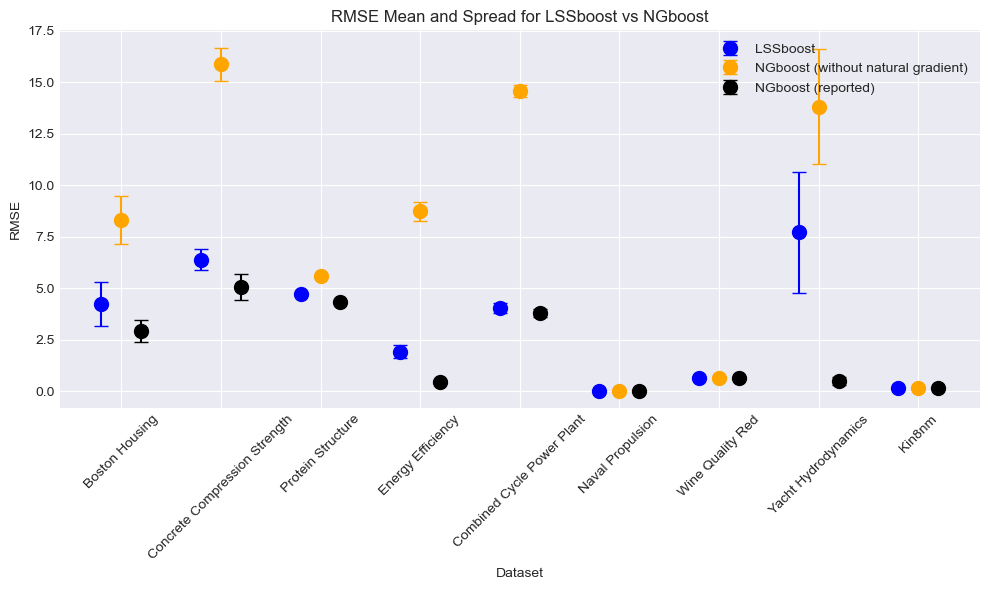

In [4]:
df_lssboost = pd.read_csv('results/LSSboost_logloss.csv', index_col=['dset']).iloc[:-1,:]
df_ngboost = pd.read_csv('results/NGboost_logloss_nonatural.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset']).iloc[:-1,:]

df_lssboost = df_lssboost.add_prefix('lss_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_RMSE-mean']
stds_lssboost = merged_df['lss_RMSE-std']
means_ngboost = merged_df['ngb_RMSE-mean']
stds_ngboost = merged_df['ngb_RMSE-std']
means_rep_ngboost = merged_df['rep_RMSE-mean']
stds_rep_ngboost = merged_df['rep_RMSE-std']

x = np.arange(len(datasets))  # the label locations

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.2  # the width of the bars
# Adjusting the positions slightly to avoid overlapping
# Calculate positions for each group
positions_lssboost = x - width
positions_ngboost = x
positions_rep_ngboost = x + width
dot_size = 10

# Plotting LSSboost means as blue dots with error bars for standard deviation
plt.errorbar(positions_lssboost, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost', markersize=dot_size)

# Plotting NGboost means as orange dots with error bars for standard deviation
plt.errorbar(positions_ngboost, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (without natural gradient)', markersize=dot_size)

# Plotting NGboost reported means with error bars
plt.errorbar(positions_rep_ngboost, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Mean and Spread for LSSboost vs NGboost')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.legend()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('RMSE_evaluation_probdist.png')
plt.show()


In [6]:
merged_df_tp = merged_df.round(3).T
merged_df_tp = merged_df_tp.drop(['ngb_time', 'lss_time'], axis=0)
df_output = merged_df_tp.copy()
# Rename the methods to be consistent and easily identifiable.

method_mapping = {
    'lss': 'LSSboost',
    'ngb': 'NGboost',
    'rep': 'NGB (reported)'
}

# Extract the method, metric type, and statistic from the 'Unnamed: 0' column.

df_output[['Method', 'Metric', 'Statistic']] = df_output.index.str.extract(
    r'(\w+)_([A-Z]+)-(\w+)', expand=True).values

# Map the extracted method names to the user-friendly names.
df_output['Method'] = df_output['Method'].map(method_mapping)
# Drop the now-redundant 'Unnamed: 0' column.
#f_output.drop(columns='Unnamed: 0', inplace=True)



# We will pivot the table to get the Method as the index and multi-level columns for each dataset and statistic.
pivot_df = df_output.pivot_table(index='Method', columns=['Metric', df_output.groupby(['Method', 'Metric']).cumcount()],values=df_output.columns[1:-3], aggfunc='first')
pivot_df.to_csv('results_RMSE.csv')
pivot_df

dset           Boston Housing                        \
Metric                    NLL           RMSE          
                            0       1      0      1   
Method                                                
LSSboost                2.589   0.159  4.248  1.071   
NGB (reported)          2.430   0.150  2.940  0.530   
NGboost                10.555  11.026  8.309  1.172   

dset           Combined Cycle Power Plant                        \
Metric                                NLL           RMSE          
                                        0      1       0      1   
Method                                                            
LSSboost                            2.881  0.313   4.043  0.257   
NGB (reported)                      2.790  0.110   3.790  0.180   
NGboost                             3.772  0.048  14.590  0.294   

dset           Concrete Compression Strength         ... Naval Propulsion  \
Metric                                   NLL         ...             RMSE   
                                           0      1  ...                0   
Method                                               ...                    
LSSboost                               3.219  0.205  ...            0.007   
NGB (reported)                         3.040  0.170  ...            0.000   
NGboost                                3.929  0.113  ...            0.002   

dset                  Protein Structure                       \
Metric                              NLL          RMSE          
                    1                 0      1      0      1   
Method                                                         
LSSboost        0.001             2.942  0.076  4.724  0.030   
NGB (reported)  0.000             2.810  0.030  4.330  0.030   
NGboost         0.000             3.037  0.019  5.582  0.052   

dset           Yacht Hydrodynamics                         
Metric                         NLL            RMSE         
                                 0       1       0      1  
Method                                                     
LSSboost                     0.577   0.521   7.709  2.958  
NGB (reported)               0.200   0.260   0.500  0.200  
NGboost                     11.548  12.415  13.817  2.794  

[3 rows x 32 columns]

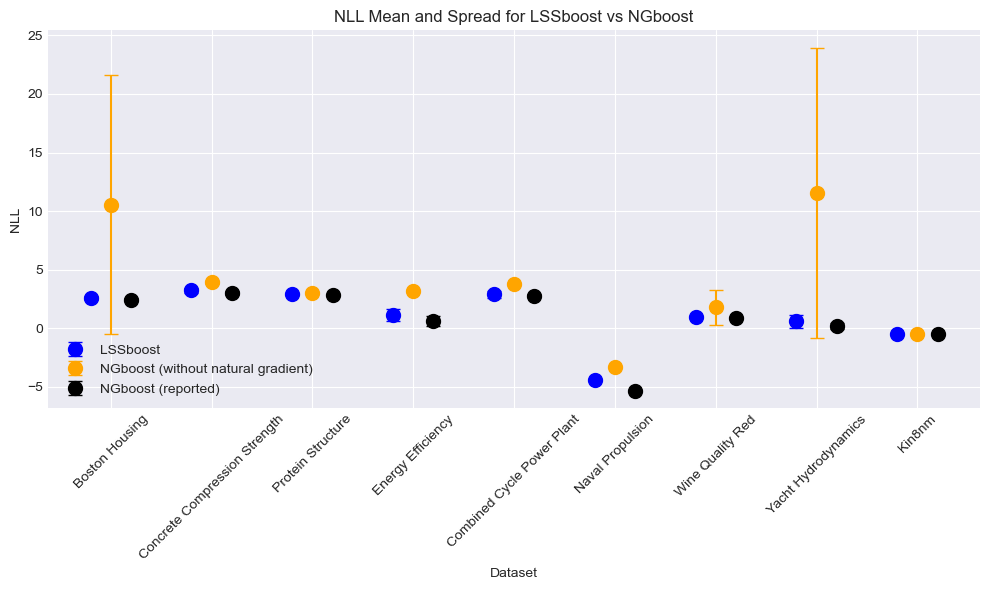

In [5]:
df_lssboost = pd.read_csv('results/LSSboost_logloss.csv', index_col=['dset']).iloc[:-1,:]
df_ngboost = pd.read_csv('results/NGboost_logloss_nonatural.csv', index_col=['dset'])
df_ngboost_rep = pd.read_csv('results/NGBoost_reported.csv', index_col=['dset']).iloc[:-1,:]

df_lssboost = df_lssboost.add_prefix('lss_')
df_ngboost = df_ngboost.add_prefix('ngb_')
df_ngboost_rep = df_ngboost_rep.add_prefix('rep_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)
merged_df = merged_df.merge(df_ngboost_rep, left_index=True, right_index=True)

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_NLL-mean']
stds_lssboost = merged_df['lss_NLL-std']
means_ngboost = merged_df['ngb_NLL-mean']
stds_ngboost = merged_df['ngb_NLL-std']
means_rep_ngboost = merged_df['rep_NLL-mean']
stds_rep_ngboost = merged_df['rep_NLL-std']

x = np.arange(len(datasets))  # the label locations

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.2  # the width of the bars
# Adjusting the positions slightly to avoid overlapping
# Calculate positions for each group
positions_lssboost = x - width
positions_ngboost = x
positions_rep_ngboost = x + width
dot_size = 10

# Plotting LSSboost means as blue dots with error bars for standard deviation
plt.errorbar(positions_lssboost, means_lssboost, yerr=stds_lssboost, fmt='o', color='blue', ecolor='blue', capsize=5, label='LSSboost', markersize=dot_size)

# Plotting NGboost means as orange dots with error bars for standard deviation
plt.errorbar(positions_ngboost, means_ngboost, yerr=stds_ngboost, fmt='o', color='orange', ecolor='orange', capsize=5, label='NGboost (without natural gradient)', markersize=dot_size)

# Plotting NGboost reported means with error bars
plt.errorbar(positions_rep_ngboost, means_rep_ngboost, yerr=stds_rep_ngboost, fmt='o', color='black', ecolor='black', capsize=5, label='NGboost (reported)', markersize=dot_size)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset')
ax.set_ylabel('NLL')
ax.set_title('NLL Mean and Spread for LSSboost vs NGboost')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.legend()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('NLL_evaluation_probdist.png')
plt.show()


In [81]:
merged_df_tp = merged_df.round(3).T
merged_df_tp = merged_df_tp.drop(['ngb_time', 'lss_time'], axis=0)
df_output = merged_df_tp.copy()
# Rename the methods to be consistent and easily identifiable.

method_mapping = {
    'lss': 'LSSboost',
    'ngb': 'NGboost',
    'rep': 'NGB (reported)'
}

# Extract the method, metric type, and statistic from the 'Unnamed: 0' column.

df_output[['Method', 'Metric', 'Statistic']] = df_output.index.str.extract(
    r'(\w+)_([A-Z]+)-(\w+)', expand=True).values

# Map the extracted method names to the user-friendly names.
df_output['Method'] = df_output['Method'].map(method_mapping)
# Drop the now-redundant 'Unnamed: 0' column.
#f_output.drop(columns='Unnamed: 0', inplace=True)



# We will pivot the table to get the Method as the index and multi-level columns for each dataset and statistic.
pivot_df = df_output.pivot_table(index='Method', columns=['Metric', df_output.groupby(['Method', 'Metric']).cumcount()],values=df_output.columns[1:-3], aggfunc='first')
pivot_df.to_csv('results_NLL.csv')
pivot_df

dset           Boston Housing                      Combined Cycle Power Plant  \
Metric                    NLL          RMSE                               NLL   
                            0      1      0      1                          0   
Method                                                                          
LSSboost                2.589  0.159  4.248  1.071                      2.881   
NGB (reported)          2.430  0.150  2.940  0.530                      2.790   
NGboost                10.300  9.197  2.673  0.442                      2.793   

dset                                Concrete Compression Strength         ...  \
Metric                  RMSE                                  NLL         ...   
                    1      0      1                             0      1  ...   
Method                                                                    ...   
LSSboost        0.313  4.043  0.257                         3.219  0.205  ...   
NGB (reported)  0.110  3.790  0.180                         3.040  0.170  ...   
NGboost         0.202  3.620  0.195                         3.426  0.414  ...   

dset           Naval Propulsion        Protein Structure                      \
Metric                     RMSE                      NLL          RMSE         
                              0      1                 0      1      0     1   
Method                                                                         
LSSboost                  0.007  0.001             2.942  0.076  4.724  0.03   
NGB (reported)            0.000  0.000             2.810  0.030  4.330  0.03   
NGboost                   0.002  0.000             2.851  0.020  4.516  0.04   

dset           Yacht Hydrodynamics                       
Metric                         NLL          RMSE         
                                 0      1      0      1  
Method                                                   
LSSboost                     0.577  0.521  7.709  2.958  
NGB (reported)               0.200  0.260  0.500  0.200  
NGboost                      2.116  2.354  0.559  0.172  

[3 rows x 32 columns]

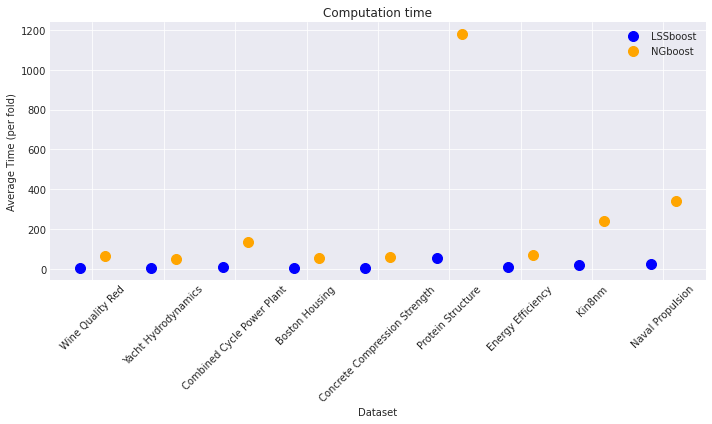

In [10]:
df_lssboost = pd.read_csv('results/LSSboost_logloss.csv', index_col=['dset']).iloc[:-1,:]
df_ngboost = pd.read_csv('results/NGboost_logloss.csv', index_col=['dset'])

df_lssboost = df_lssboost.add_prefix('lss_')
df_ngboost = df_ngboost.add_prefix('ngb_')

merged_df = df_lssboost.merge(df_ngboost, left_index=True, right_index=True)

# Preparing data for error bars visualization
datasets = merged_df.index
means_lssboost = merged_df['lss_time']
means_ngboost = merged_df['ngb_time']

x = np.arange(len(datasets))  # the label locations

%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35  # the width of the bars
# Adjusting the positions slightly to avoid overlapping
positions_lssboost = x - width/2
positions_ngboost = x + width/2
dot_size = 10

# Plotting LSSboost means as blue dots with error bars for standard deviation
plt.errorbar(positions_lssboost, means_lssboost, fmt='o', color='blue', capsize=5, label='LSSboost', markersize=dot_size)

# Plotting NGboost means as orange dots with error bars for standard deviation
plt.errorbar(positions_ngboost, means_ngboost, fmt='o', color='orange', capsize=5, label='NGboost', markersize=dot_size)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Dataset')
ax.set_ylabel('Average Time (per fold)')
ax.set_title('Computation time')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45)
ax.legend()

plt.style.use('seaborn-darkgrid')
plt.tight_layout()
plt.savefig('time_evaluation_probdist.png')
plt.show()
